# Interpretability Experiment - DenseNet121 CNN

This notebook mirrors Zhigang's `run_interpretability.ipynb` experiment structure as closely as possible, but replaces the DeiT/Swin model loading and heatmap generation with your DenseNet121 CNN Grad-CAM.

It keeps the same major sections:

1. Environment setup
2. Model loading
3. Clean single-label sample index
4. Single image demo
5. Bounding box evaluation
6. BBox visualization
7. Per-label average heatmap

Use this notebook for direct comparison against the original interpretability notebook.

### Environment Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "run_experiment.py").exists() and (REPO_ROOT.parent / "src" / "run_experiment.py").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "run_experiment.py").exists():
    raise RuntimeError(f"Could not resolve repo root from {Path.cwd()}")

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

DENSENET_CONFIG = Path("configs/cnn_densenet121_baseline.yaml")
DENSENET_CKPT = Path("artifacts/models/densenet121_chexnet_style_baseline_best.pt")
TEST_MANIFEST = Path("../data/manifests/test.csv")
BBOX_CSV = Path("../data/annotations/BBox_list_2017.csv")

OUTPUT_DIR = Path("outputs/interpretability_notebook_densenet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"repo: {REPO_ROOT}")
print(f"device: {device}")
print(f"torch: {torch.__version__}")
print(f"checkpoint exists: {DENSENET_CKPT.exists()} -> {DENSENET_CKPT}")



libgomp: Invalid value for environment variable OMP_NUM_THREADS


repo: /root/visiontrans_diagnostics_gradcam_heatmap
device: cuda
torch: 2.5.1+cu124
checkpoint exists: True -> artifacts/models/densenet121_chexnet_style_baseline_best.pt


### Load model (DenseNet121 CNN)

In [2]:
from config import load_config
from data import NIH_CHEST_XRAY_LABELS, build_image_transform
from models import build_model
from interpretability import GradCAM, overlay_heatmap, resolve_cnn_target_layer

config = load_config(DENSENET_CONFIG)
densenet = build_model(config).to(device)
checkpoint = torch.load(DENSENET_CKPT, map_location=device)
densenet.load_state_dict(checkpoint["model_state_dict"])
densenet.eval()

params = sum(p.numel() for p in densenet.parameters()) / 1e6
print(f"DenseNet121: {params:.1f}M params")
print("checkpoint epoch:", checkpoint.get("epoch"))
print("checkpoint val mean AUC:", checkpoint.get("val_mean_auc"))


/tmp/ipykernel_2460/3185923434.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(DENSENET_CKPT, map_location=device)


DenseNet121: 7.0M params
checkpoint epoch: 6
checkpoint val mean AUC: 0.8342028178645146


### Build Clean Sample Index

We subset the test set to single-label ground-truth images where the DenseNet121 argmax prediction matches the GT label. This follows the same simplifying assumption as the original notebook: it converts a multi-label problem into a cleaner single-label visualization setting.

In [3]:
from torch.utils.data import Dataset, DataLoader

LABEL_COLS = list(NIH_CHEST_XRAY_LABELS)

image_size = int(config.get("data", {}).get("image_size", 224))
num_channels = int(config.get("data", {}).get("num_channels", 1))
_TRANSFORM = build_image_transform(image_size=image_size, num_channels=num_channels, is_train=False)

class _ImgDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        image = Image.open(self.paths[i]).convert("L" if num_channels == 1 else "RGB")
        return _TRANSFORM(image)


def build_clean_index(test_df, model, device, batch_size=96):
    single_df = test_df[test_df[LABEL_COLS].sum(axis=1) == 1].reset_index(drop=True)
    print(f"Single-label samples: {len(single_df)}")

    gt_idx = torch.tensor(single_df[LABEL_COLS].values, dtype=torch.float32).argmax(dim=1)

    loader = DataLoader(
        _ImgDataset(single_df["image_path"].tolist()),
        batch_size=batch_size,
        num_workers=4,
        pin_memory=torch.cuda.is_available(),
    )

    preds = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device, non_blocking=True)
            preds.append(torch.sigmoid(model(batch)).argmax(dim=1).cpu())

    ok = torch.cat(preds) == gt_idx
    clean_df = single_df[ok.numpy().astype(bool)].copy().reset_index(drop=True)

    def _gt_label(row):
        for col in LABEL_COLS:
            if row[col] == 1:
                return col

    clean_df["gt_label"] = clean_df.apply(_gt_label, axis=1)
    print(f"Clean samples (DenseNet argmax == GT): {len(clean_df)}")
    for label in LABEL_COLS:
        n = (clean_df["gt_label"] == label).sum()
        if n > 0:
            print(f"{label:22s}: {n}")
    return clean_df


test_df = pd.read_csv(TEST_MANIFEST)
clean_index = build_clean_index(test_df, densenet, device)


Single-label samples: 8002
Clean samples (DenseNet argmax == GT): 3195
Atelectasis           : 405
Cardiomegaly          : 203
Effusion              : 743
Infiltration          : 780
Mass                  : 176
Nodule                : 140
Pneumothorax          : 452
Consolidation         : 14
Edema                 : 64
Emphysema             : 141
Fibrosis              : 16
Pleural_Thickening    : 39
Hernia                : 22


In [4]:
LABEL_TO_IDX = {label: i for i, label in enumerate(LABEL_COLS)}
densenet_gcam_fn = GradCAM(densenet, resolve_cnn_target_layer(densenet))
print("DenseNet Grad-CAM target layer:", resolve_cnn_target_layer(densenet).__class__.__name__)


DenseNet Grad-CAM target layer: _DenseBlock


### Single Image Demo
Visualize a single sample image first.

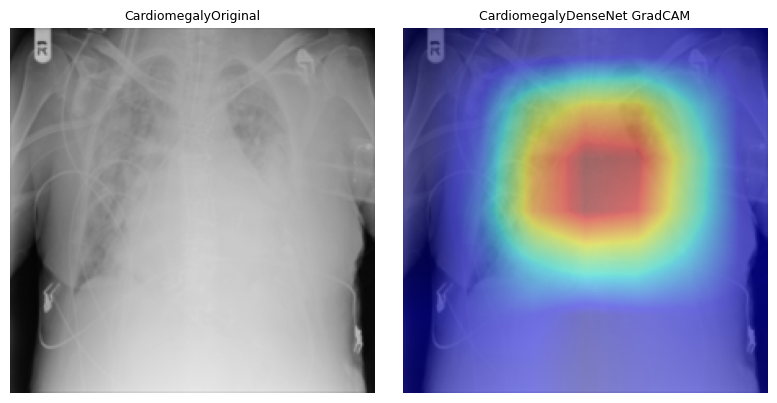

probability: 0.8494855761528015


In [6]:
def load_image(image_path, device):
    img = Image.open(image_path).convert("L" if num_channels == 1 else "RGB")
    tensor = _TRANSFORM(img).unsqueeze(0).to(device)
    gray = np.array(img.convert("L").resize((224, 224))) / 255.0
    return tensor, gray.astype(np.float32)

preferred_label = "Cardiomegaly"
if (clean_index["gt_label"] == preferred_label).any():
    sample = clean_index[clean_index["gt_label"] == preferred_label].iloc[0]
else:
    sample = clean_index.iloc[0]
    preferred_label = sample["gt_label"]

class_idx = LABEL_TO_IDX[preferred_label]
tensor, gray = load_image(sample["image_path"], device)
hm_densenet_cam, probability = densenet_gcam_fn.generate(tensor, class_idx)
densenet_gcam_fn.model.zero_grad(set_to_none=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (title, img) in zip(axes, [
    ("Original", gray),
    ("DenseNet GradCAM", overlay_heatmap(Image.fromarray((gray * 255).astype(np.uint8)), hm_densenet_cam)),
]):
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=1)
    ax.set_title(f"{preferred_label}{title}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("probability:", probability)


### Bounding Box Evaluation
Few samples have bounding box annotations. We visualize how DenseNet Grad-CAM aligns with the NIH bounding boxes and compute the same style of IoU / attention ratio / pointing-game metrics used in the original notebook.

In [7]:
bbox_df = pd.read_csv(BBOX_CSV, header=0).iloc[:, :6]
bbox_df.columns = ["image_name", "label", "x", "y", "w", "h"]

merged = bbox_df[bbox_df["image_name"].isin(set(clean_index["image_name"]))].merge(
    clean_index[["image_name", "image_path", "gt_label"]], on="image_name", how="inner"
)
merged = merged[merged["label"] == merged["gt_label"]]

print("Bbox samples available per disease (after clean index filter):")
print(merged["label"].value_counts().to_string())


Bbox samples available per disease (after clean index filter):
label
Cardiomegaly    45
Atelectasis     25
Effusion        20
Pneumothorax    20
Mass             8
Nodule           8


In [8]:
PRIORITY_DISEASES = ["Atelectasis", "Cardiomegaly", "Effusion", "Mass", "Pneumothorax", "Nodule"]

In [9]:
SCALE = 224 / 1024


def bbox_to_mask(x, y, w, h):
    mask = np.zeros((224, 224), dtype=np.float32)
    x1, y1 = max(0, int(x * SCALE)), max(0, int(y * SCALE))
    x2, y2 = min(224, int((x + w) * SCALE)), min(224, int((y + h) * SCALE))
    mask[y1:y2, x1:x2] = 1.0
    return mask


def compute_iou(heatmap, gt_mask):
    pred = (heatmap >= 0.5).astype(np.float32)
    intersection = (pred * gt_mask).sum()
    union = np.clip(pred + gt_mask, 0, 1).sum()
    return float(intersection / (union + 1e-8))


def bbox_attention_ratio(heatmap, gt_mask):
    inside = float(heatmap[gt_mask > 0].mean()) if gt_mask.sum() > 0 else 0.0
    return inside / (float(heatmap.mean()) + 1e-8)


def pointing_game(heatmap, gt_mask, border=0):
    h = heatmap.copy()
    if border > 0:
        h[:border, :] = -1
        h[-border:, :] = -1
        h[:, :border] = -1
        h[:, -border:] = -1
    y, x = np.unravel_index(np.argmax(h), h.shape)
    return float(gt_mask[y, x] > 0)


In [10]:
N_SAMPLES = 10

records = []
for disease in PRIORITY_DISEASES:
    samples = merged[merged["label"] == disease].head(N_SAMPLES)
    if samples.empty:
        print(f"[{disease}] no clean bbox samples")
        continue
    class_idx = LABEL_TO_IDX[disease]
    for _, row in samples.iterrows():
        tensor, gray = load_image(row["image_path"], device)
        gt_mask = bbox_to_mask(row["x"], row["y"], row["w"], row["h"])
        hm_dg, probability = densenet_gcam_fn.generate(tensor, class_idx)
        densenet_gcam_fn.model.zero_grad(set_to_none=True)
        records.append({
            "disease": disease,
            "iou_densenet_cam": compute_iou(hm_dg, gt_mask),
            "ar_densenet_cam": bbox_attention_ratio(hm_dg, gt_mask),
            "pg_densenet_cam": pointing_game(hm_dg, gt_mask, border=0),
            "probability": probability,
        })

results_df = pd.DataFrame(records)
if len(results_df):
    display(results_df.groupby("disease").mean().round(3))
else:
    print("No bbox records were evaluated.")


,iou_densenet_cam,ar_densenet_cam,pg_densenet_cam,probability
disease,,,,
Atelectasis,0.102,2.406,0.4,0.812
Cardiomegaly,0.604,3.410,1.0,0.868
Effusion,0.157,3.221,0.4,0.902
Mass,0.168,3.694,0.5,0.934
Nodule,0.017,3.085,0.0,0.862
Pneumothorax,0.147,1.873,0.3,0.902


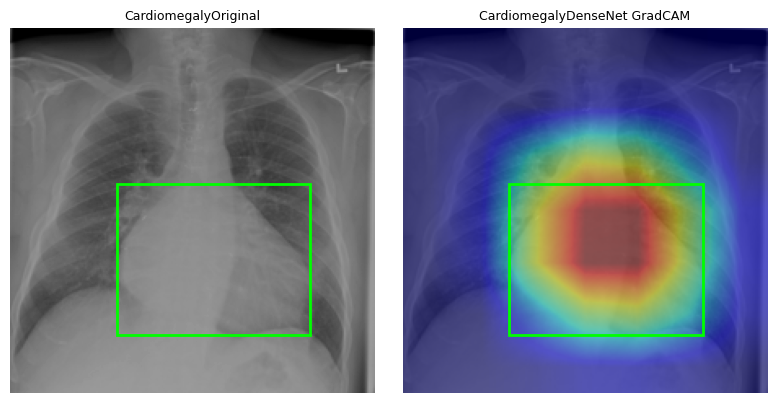

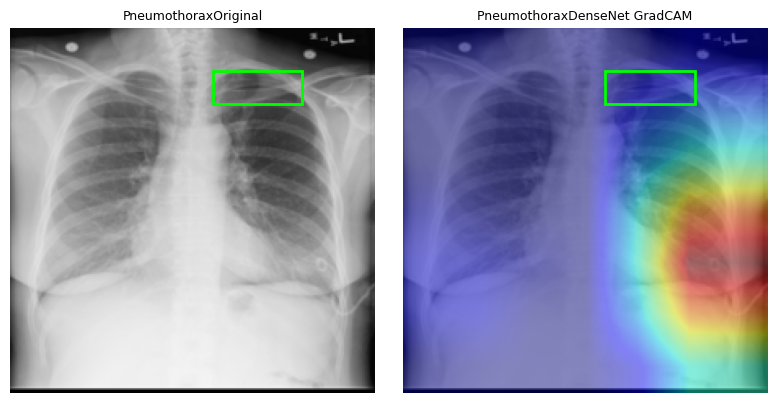

In [12]:
import matplotlib.patches as patches

for disease, sample_idx in [("Cardiomegaly", 0), ("Pneumothorax", 0)]:
    disease_rows = merged[merged["label"] == disease]
    if len(disease_rows) <= sample_idx:
        print(f"[{disease}] no bbox sample at index {sample_idx}")
        continue
    row = disease_rows.iloc[sample_idx]
    class_idx = LABEL_TO_IDX[disease]
    tensor, gray = load_image(row["image_path"], device)
    gt_mask = bbox_to_mask(row["x"], row["y"], row["w"], row["h"])

    hm_dg, probability = densenet_gcam_fn.generate(tensor, class_idx)
    densenet_gcam_fn.model.zero_grad(set_to_none=True)

    ys, xs = np.where(gt_mask > 0)
    x1, x2, y1, y2 = xs.min(), xs.max(), ys.min(), ys.max()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, (title, img) in zip(axes, [
        ("Original", gray),
        ("DenseNet GradCAM", overlay_heatmap(Image.fromarray((gray * 255).astype(np.uint8)), hm_dg)),
    ]):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=1)
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                        linewidth=2, edgecolor="lime", facecolor="none"))
        ax.set_title(f"{disease}{title}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


### Per-label Average Heatmap
We calculate DenseNet Grad-CAM heatmaps for all clean samples of each label and average them to see the CNN's general focus pattern for each disease.

[Atelectasis] 0/405...
[Atelectasis] 100/405...
[Atelectasis] 200/405...
[Atelectasis] 300/405...
[Atelectasis] 400/405...


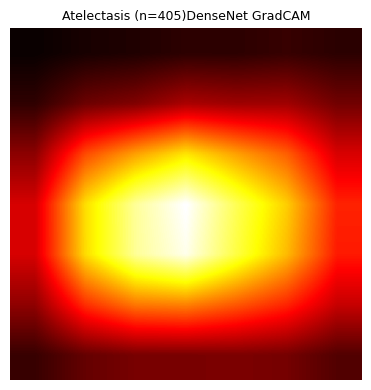

[Cardiomegaly] 0/203...
[Cardiomegaly] 100/203...
[Cardiomegaly] 200/203...


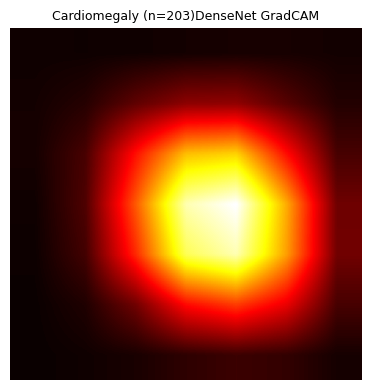

[Effusion] 0/743...
[Effusion] 100/743...
[Effusion] 200/743...
[Effusion] 300/743...
[Effusion] 400/743...
[Effusion] 500/743...
[Effusion] 600/743...
[Effusion] 700/743...


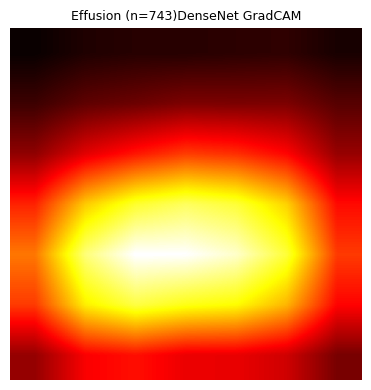

[Infiltration] 0/780...
[Infiltration] 100/780...
[Infiltration] 200/780...
[Infiltration] 300/780...
[Infiltration] 400/780...
[Infiltration] 500/780...
[Infiltration] 600/780...
[Infiltration] 700/780...


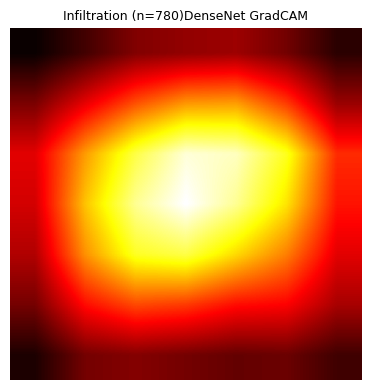

[Mass] 0/176...
[Mass] 100/176...


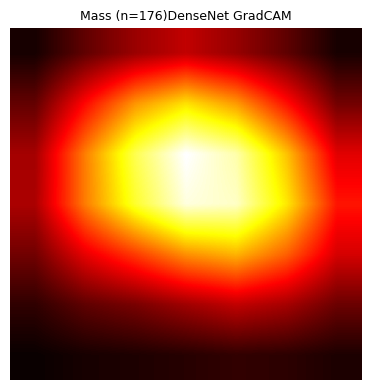

[Nodule] 0/140...
[Nodule] 100/140...


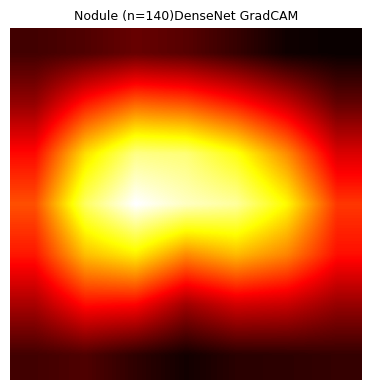

[Pneumothorax] 0/452...
[Pneumothorax] 100/452...
[Pneumothorax] 200/452...
[Pneumothorax] 300/452...
[Pneumothorax] 400/452...


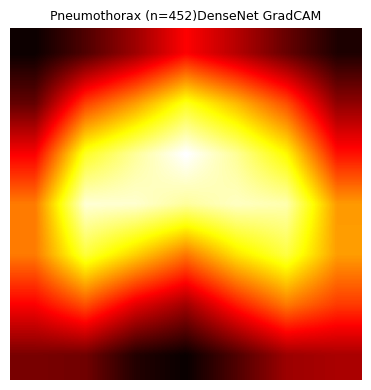

[Consolidation] 0/14...


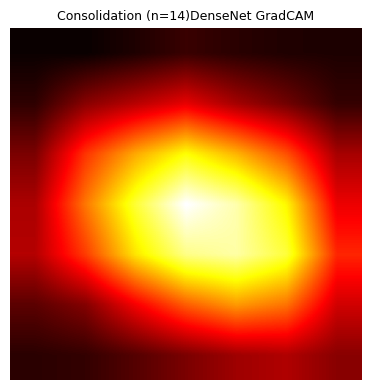

[Edema] 0/64...


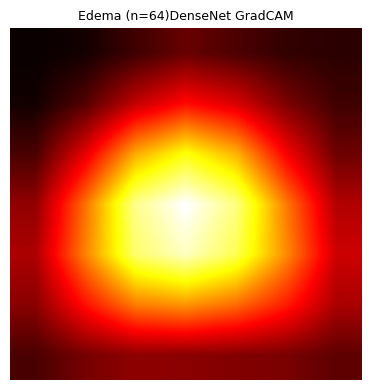

[Emphysema] 0/141...
[Emphysema] 100/141...


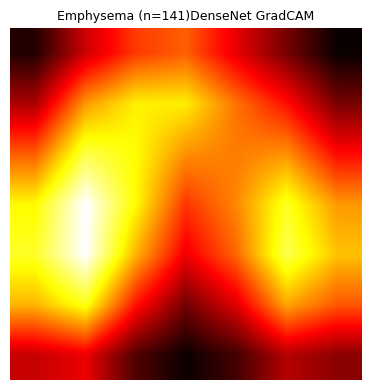

[Fibrosis] 0/16...


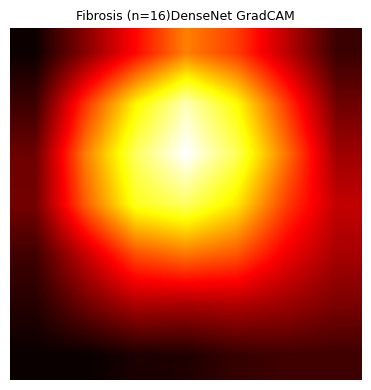

[Pleural_Thickening] 0/39...


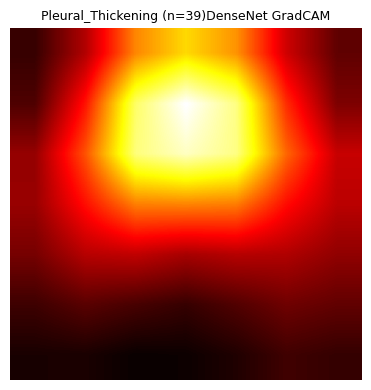

[Hernia] 0/22...


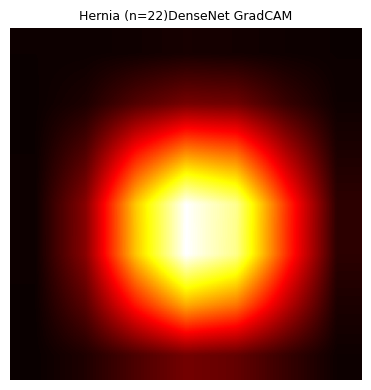

In [14]:
avg_dir = Path("outputs/interpretability_notebook_densenet/avg_heatmaps")
avg_dir.mkdir(parents=True, exist_ok=True)


def norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

for label in LABEL_COLS:
    label_df = clean_index[clean_index["gt_label"] == label]
    n = len(label_df)
    if n == 0:
        continue

    class_idx = LABEL_TO_IDX[label]
    acc_dg = None

    for idx, (_, row) in enumerate(label_df.iterrows()):
        if idx % 100 == 0:
            print(f"[{label}] {idx}/{n}...")
        tensor, _ = load_image(row["image_path"], device)
        hm_dg, _ = densenet_gcam_fn.generate(tensor, class_idx)
        densenet_gcam_fn.model.zero_grad(set_to_none=True)
        if device.type == "cuda" and idx % 50 == 0:
            torch.cuda.empty_cache()

        if acc_dg is None:
            acc_dg = hm_dg.copy()
        else:
            acc_dg += hm_dg

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(norm(acc_dg / n), cmap="hot", vmin=0, vmax=1)
    ax.set_title(f"{label} (n={n})DenseNet GradCAM", fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(avg_dir / f"avg_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
densenet_gcam_fn.remove_hooks()